Welcome. This notebook can be used to try out the Stable Image Services. This implementation can be used in your production environment if you are developing an application using the API.

New to colab? Just hit the play button on each of the cells and follow instructions.

You will need an account on https://platform.stability.ai/ to use the features.

Have fun and do great things.

In [1]:
#@title Install requirements
from io import BytesIO
import IPython
import json
import os
from PIL import Image
import requests
import time
from google.colab import output

In [2]:
#@title Connect to the Stability API

import getpass
# @markdown To get your API key visit https://platform.stability.ai/account/keys
STABILITY_KEY = getpass.getpass('Enter your API Key')



Enter your API Key··········


In [3]:
#@title Define functions

def send_generation_request(
    host,
    params,
    files = None
):
    headers = {
        "Accept": "image/*",
        "Authorization": f"Bearer {STABILITY_KEY}"
    }

    if files is None:
        files = {}

    # Encode parameters
    image = params.pop("image", None)
    mask = params.pop("mask", None)
    if image is not None and image != '':
        files["image"] = open(image, 'rb')
    if mask is not None and mask != '':
        files["mask"] = open(mask, 'rb')
    if len(files)==0:
        files["none"] = ''

    # Send request
    print(f"Sending REST request to {host}...")
    response = requests.post(
        host,
        headers=headers,
        files=files,
        data=params
    )
    if not response.ok:
        raise Exception(f"HTTP {response.status_code}: {response.text}")

    return response

def send_async_generation_request(
    host,
    params,
    files = None
):
    headers = {
        "Accept": "application/json",
        "Authorization": f"Bearer {STABILITY_KEY}"
    }

    if files is None:
        files = {}

    # Encode parameters
    image = params.pop("image", None)
    mask = params.pop("mask", None)
    if image is not None and image != '':
        files["image"] = open(image, 'rb')
    if mask is not None and mask != '':
        files["mask"] = open(mask, 'rb')
    if len(files)==0:
        files["none"] = ''

    # Send request
    print(f"Sending REST request to {host}...")
    response = requests.post(
        host,
        headers=headers,
        files=files,
        data=params
    )
    if not response.ok:
        raise Exception(f"HTTP {response.status_code}: {response.text}")

    # Process async response
    response_dict = json.loads(response.text)
    generation_id = response_dict.get("id", None)
    assert generation_id is not None, "Expected id in response"

    # Loop until result or timeout
    timeout = int(os.getenv("WORKER_TIMEOUT", 500))
    start = time.time()
    status_code = 202
    while status_code == 202:
        print(f"Polling results at https://api.stability.ai/v2beta/results/{generation_id}")
        response = requests.get(
            f"https://api.stability.ai/v2beta/results/{generation_id}",
            headers={
                **headers,
                "Accept": "*/*"
            },
        )

        if not response.ok:
            raise Exception(f"HTTP {response.status_code}: {response.text}")
        status_code = response.status_code
        time.sleep(10)
        if time.time() - start > timeout:
            raise Exception(f"Timeout after {timeout} seconds")

    return response

# Generate

Stable Image services include:

- Ultra: Our most advanced text to image generation service.

- SD3.5: Generate using Stable Diffusion 3.5 models: SD3.5 Large, SD3.5 Large Turbo, SD3.5 Medium, and SD3.5 Flash. Try the [SD3 notebook](https://colab.research.google.com/github/stability-ai/stability-sdk/blob/main/nbs/SD3_API.ipynb).

- Core: Our primary service for text-to-image generation.

See https://platform.stability.ai/docs/api-reference#tag/Generate

Pricing page: https://platform.stability.ai/pricing

Try these services out in the sections below. Check back in for regular updates.

Feedback welcome.

Sending REST request to https://api.stability.ai/v2beta/stable-image/generate/sd3...
Saved image generated_626196583.jpeg


<IPython.core.display.Javascript object>

Result image:


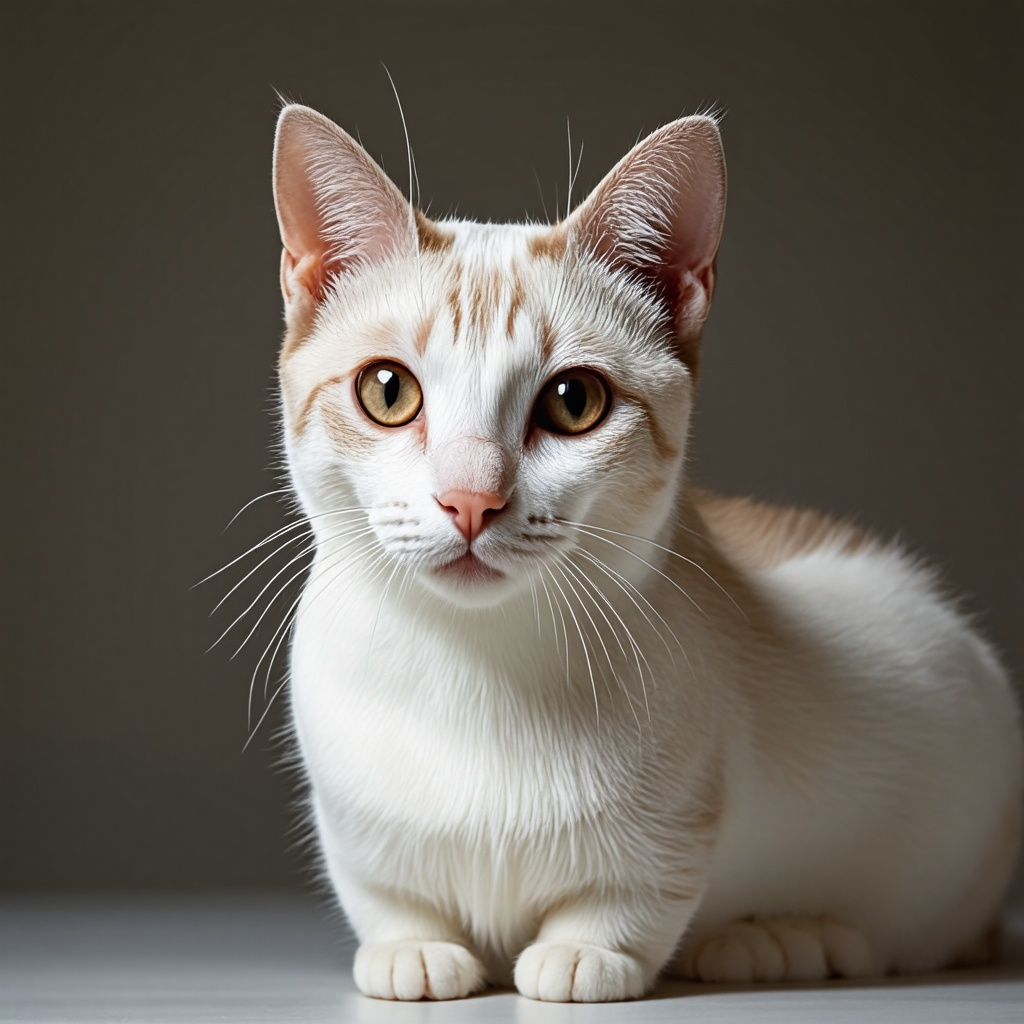

In [12]:
#@title SD3.5

prompt = "a white siamese cat, studio lighting, photorealistic" #@param {type:"string"}
negative_prompt = "" #@param {type:"string"}
aspect_ratio = "1:1" #@param ["21:9", "16:9", "3:2", "5:4", "1:1", "4:5", "2:3", "9:16", "9:21"]
seed = 0 #@param {type:"integer"}
output_format = "jpeg" #@param ["jpeg", "png"]
model = "sd3.5-flash" #@param ["sd3.5-large", "sd3.5-large-turbo", "sd3.5-medium", "sd3.5-flash"]
style_preset = "None" #@param ["None","3d-model", "analog-film", "anime", "cinematic", "comic-book", "digital-art", "enhance", "fantasy-art", "isometric", "line-art", "low-poly", "modeling-compound", "neon-punk", "origami", "photographic", "pixel-art", "tile-texture"]

host = f"https://api.stability.ai/v2beta/stable-image/generate/sd3"

params = {
    "prompt" : prompt,
    "negative_prompt" : negative_prompt if model != "sd3.5-large-turbo" and model != "sd3.5-flash" else "",
    "aspect_ratio" : aspect_ratio,
    "seed" : seed,
    "output_format" : output_format,
    "model" : model,
    "mode" : "text-to-image"
}

if style_preset != "None":
    params["style_preset"] = style_preset

response = send_generation_request(
    host,
    params
)

# Decode response
output_image = response.content
finish_reason = response.headers.get("finish-reason")
seed = response.headers.get("seed")

# Check for NSFW classification
if finish_reason == 'CONTENT_FILTERED':
    raise Warning("Generation failed NSFW classifier")

# Save and display result
generated = f"generated_{seed}.{output_format}"
with open(generated, "wb") as f:
    f.write(output_image)
print(f"Saved image {generated}")

output.no_vertical_scroll()
print("Result image:")
IPython.display.display(Image.open(generated))

Sending REST request to https://api.stability.ai/v2beta/stable-image/generate/sd3...
Saved image generated_2613732666.jpeg


<IPython.core.display.Javascript object>

Result image:


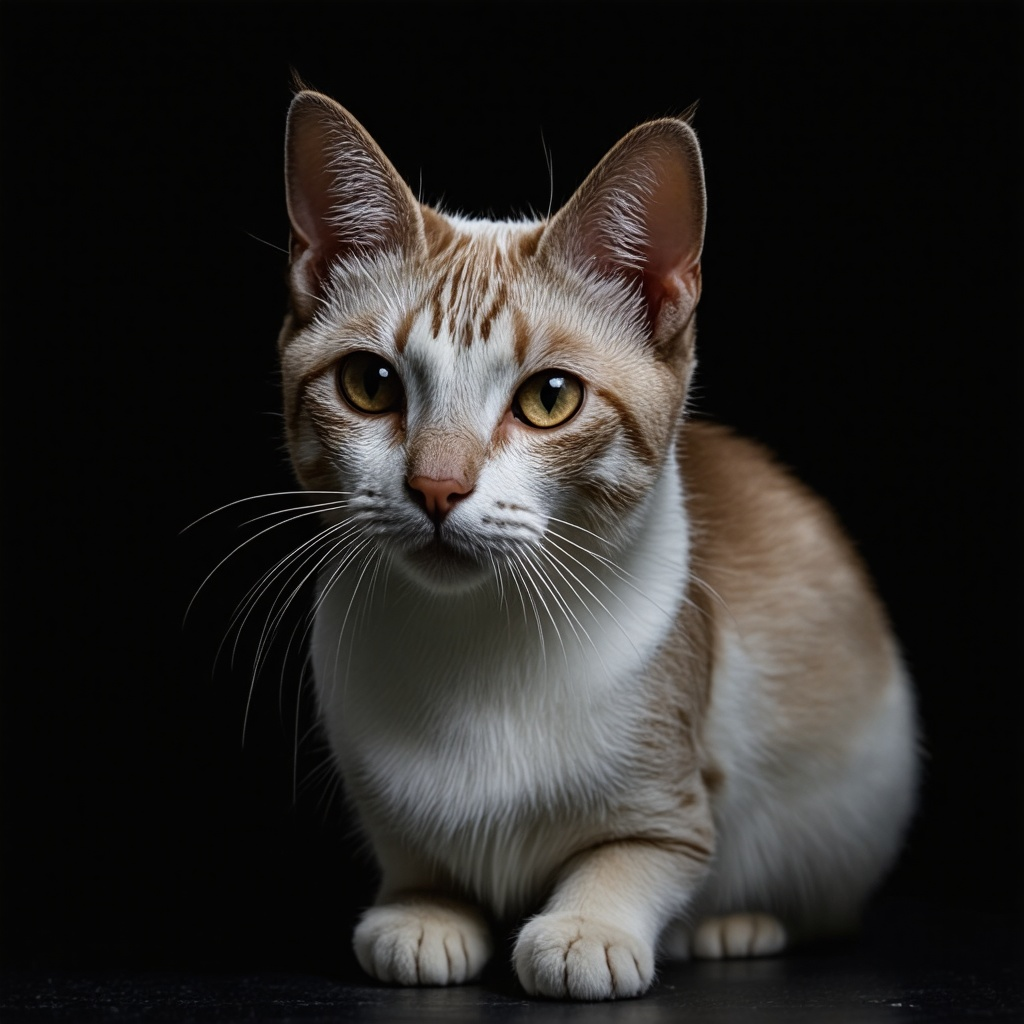

In [13]:
#@title SD3.5

prompt = "a white siamese cat, dramatic lighting, dark background, cinematic" #@param {type:"string"}
negative_prompt = "" #@param {type:"string"}
aspect_ratio = "1:1" #@param ["21:9", "16:9", "3:2", "5:4", "1:1", "4:5", "2:3", "9:16", "9:21"]
seed = 0 #@param {type:"integer"}
output_format = "jpeg" #@param ["jpeg", "png"]
model = "sd3.5-flash" #@param ["sd3.5-large", "sd3.5-large-turbo", "sd3.5-medium", "sd3.5-flash"]
style_preset = "None" #@param ["None","3d-model", "analog-film", "anime", "cinematic", "comic-book", "digital-art", "enhance", "fantasy-art", "isometric", "line-art", "low-poly", "modeling-compound", "neon-punk", "origami", "photographic", "pixel-art", "tile-texture"]

host = f"https://api.stability.ai/v2beta/stable-image/generate/sd3"

params = {
    "prompt" : prompt,
    "negative_prompt" : negative_prompt if model != "sd3.5-large-turbo" and model != "sd3.5-flash" else "",
    "aspect_ratio" : aspect_ratio,
    "seed" : seed,
    "output_format" : output_format,
    "model" : model,
    "mode" : "text-to-image"
}

if style_preset != "None":
    params["style_preset"] = style_preset

response = send_generation_request(
    host,
    params
)

# Decode response
output_image = response.content
finish_reason = response.headers.get("finish-reason")
seed = response.headers.get("seed")

# Check for NSFW classification
if finish_reason == 'CONTENT_FILTERED':
    raise Warning("Generation failed NSFW classifier")

# Save and display result
generated = f"generated_{seed}.{output_format}"
with open(generated, "wb") as f:
    f.write(output_image)
print(f"Saved image {generated}")

output.no_vertical_scroll()
print("Result image:")
IPython.display.display(Image.open(generated))